## TOV Equation Solver
### Equations to Solve

The **TOV-equation** is given by
\begin{align}
    \frac{dp}{dr} = -\frac{(p+\rho)(m+4\pi r^3 p)}{r(r-2m)}\tag{TOV}
\end{align}

Given a background metric:
\begin{align}
    ds^2 = -e^\nu dt^2 + e^{\lambda} dr^2 + r^2d\Omega^2,\tag{BG metric}
\end{align}
one is also able to obtain the $\nu$ and $\lambda$ equation:
\begin{align}
    \frac{d\nu}{dr} =&\, 2\frac{m+ 4\pi r^3 p}{r(r-2m)}\tag{$\nu$}\\[8pt]
    m(r) =&\, \frac{1}{2}r\Big(1 - e^\lambda\Big)\tag{$\lambda$}
\end{align}
Also note that we have the **conservation equation**:
\begin{align}
    \frac{dm}{dr} = 4\pi r^2 \rho\tag{Conservation}
\end{align}

We solve the conservation equation and the TOV equation first, to obtain numerical expression of $\rho, p, m$ of $r$, then match the boundary condition at $r = R$. 

## Initial Conditions

\begin{align*}
x &\equiv \sqrt{K p_c}
&
y &\equiv K p_c
\end{align*}

\begin{align*}
\rho_{\mathrm{approx}}(r)
&= \rho_c + \rho_2 r^2 + \rho_4 r^4 + \rho_6 r^6 + \rho_8 r^8
\\
\rho_c
&= p_c + \frac{x}{K}
\\
\rho_2
&= -\frac{(2y+x)(4y+x)(1+2x)\pi}{3K^2 x}
\\
\rho_4
&= \frac{(1+4y+4x)\left(34y + 448y^2 + 3x + 200y^{3/2}\right)\pi^2}{90K^3}
\\
\rho_6
&= -\frac{(2y+x)\left(3 + 580y + 25632y^2 + 57344y^3 + 24x + 5552y^{3/2} + 62080y^{5/2}\right)\pi^3}{1890K^4}
\\
\rho_8
&= \frac{\pi^4}{340200K^5}
\Big(
54591488K^5p_c^5
+ 15x
- 2y(669+3050x)
\\
&\hspace{2.2em}
+ 8704K^4p_c^4(7215+10492x)
+ 384K^3p_c^3(13745+61476x)
+ 8K^2p_c^2(4313+83508x)
\Big)
\end{align*}

\begin{align*}
m_{\mathrm{approx}}(r)
&= 4\pi r^3\left(m_c + m_2 r^2 + m_4 r^4 + m_6 r^6\right)
\\
m_c
&= \frac{\rho_c}{3}
= \frac{y+x}{3K}
\\
m_2
&= -\frac{(2y+x)(4y+x)(1+2x)\pi}{15K^2 x}
\\
m_4
&= \frac{(1+4y+4x)\left(34y + 448y^2 + 3x + 200y^{3/2}\right)\pi^2}{630K^3}
\\
m_6
&= -\frac{(2y+x)\left(3 + 580y + 25632y^2 + 57344y^3 + 24x + 5552y^{3/2} + 62080y^{5/2}\right)\pi^3}{17010K^4}
\end{align*}

\begin{align*}
\nu_{\mathrm{approx}}(r)
&= \nu_c + \nu_2 r^2 + \nu_4 r^4 + \nu_6 r^6 + \nu_8 r^8
\\
\nu_2
&= \frac{4(4y+x)\pi}{3K}
\\
\nu_4
&= -\frac{2p_c^2\left(3+14x+8y(5+16x)\right)\pi^2}{45y^{3/2}}
\\
\nu_6
&= \frac{2x\left(9-198x+64K^2p_c^2(-15+112x)-8y(139+174x)\right)\pi^3}{2835K^3}
\\
\nu_8
&= -\frac{x\left(15-2874x+512K^3p_c^3(-785+448x)-128K^2p_c^2(326+1103x)+8y(-593+2398x)\right)\pi^4}{85050K^4}
\end{align*}

\begin{align*}
\lambda_{\mathrm{approx}}(r)
&= \lambda_2 r^2 + \lambda_4 r^4 + \lambda_6 r^6 + \lambda_8 r^8
\\
\lambda_2
&= \frac{8( y + x )\pi}{3K}
\\
\lambda_4
&= -\frac{8x\left(3+4x+4y(5+7x)\right)\pi^2}{45K^2}
\\
\lambda_6
&= \frac{4x\left(27-594x+160K^2p_c^2(3+28x)-4y(365+582x)\right)\pi^3}{2835K^3}
\\
\lambda_8
&= -\frac{4x\left(15-2442x+256K^3p_c^3(-310+203x)+4y(407+818x)-32K^2p_c^2(557+2576x)\right)\pi^4}{42525K^4}
\end{align*}

\begin{align*}
p_{\mathrm{approx}}(r)
&= K\,s(r)^2
\\
s(r)
&= \frac{-1 + \sqrt{1 + 4K\,\rho_{\mathrm{approx}}(r)}}{2K}
\end{align*}


In [12]:

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys
from pathlib import Path

# add parent folder of the notebook to sys.path
sys.path.append(str(Path.cwd().parent))
from tov_series_aux import p_approx, rho_approx, m_approx, nu_approx, lambda_approx

In [3]:
# Defining a Polytropic EOS
def PolyEOS(p, n, K):
    rr = (p/K)**(n/(n+1))
    return rr

def EnergyEOS(p,n,K):
    rr = ((1+np.sqrt(4*K*p))**2-1)/(4*K)
    return rr


In [6]:
K_cgs = 1.6e5
n = 1

# The set of TOV equation and the conservation equation
def tov_rhs(r, y, eos, n, K):
    m, p = y[0], y[1]
    
    rhoEnergy = eos(p, n, K)
    
    # rhoMass = (-1 + np.sqrt(1 + 4*K*rhoEnergy)) / (2*K)    # solution to the n = 1 case
    # rhoMass = rhoEnergy + K*rhoEnergy**2 

    dm_dr = 4 * np.pi * r**2 * rhoEnergy
    dp_dr = - (rhoEnergy + p) * (m + 4*np.pi*(r**3)*p) / (r * (r - 2*m))
    
    return [dm_dr, dp_dr]

def rk4_step(func, r, y, h, eos=EnergyEOS, n=n, K=K_cgs):
    k1 = np.array(func(r, y, eos, n, K))
    k2 = np.array(func(r + h/2, y + h*k1/2, eos, n, K))
    k3 = np.array(func(r + h/2, y + h*k2/2, eos, n, K))
    k4 = np.array(func(r + h, y + h*k3, eos, n, K))
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)


In [7]:
G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
M_sun_cgs = 1.989e33   # g
cm2km = 1e5

def cgs_to_geom(p_cgs, n, K_cgs, eos=PolyEOS):

    # km^-2
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2            
    # km^(2/n)
    K_geom = K_cgs / G_cgs**(1/n) / c_cgs**(2-2/n) / cm2km**(2/n)               
    # Polytropic EOS, km^-2
    rho_geom = eos(p_geom, n, K_geom)               

    return K_geom, p_geom, rho_geom

# The input mass has unit km in geometric units, and we want to express it in solar mass
def mass_g2Msun(m_km):
    m_cgs = m_km * cm2km
    m_msun = m_cgs / G_cgs * (c_cgs**2) / M_sun_cgs

    return m_msun

In [20]:
d_num = 25
K_cgs = 1.6e5
n = 1
eps = 10**(-3)
stepArr = [4]

RR = []
MM = []

SolArr = []
RArr = []

for step_ind in stepArr:
    h = 10**(-step_ind) 
    R_arr = np.zeros(d_num)
    M_arr = np.zeros(d_num)
    Rho_arr = np.zeros(d_num)

    for i, P in tqdm(enumerate(np.logspace(33.5, 36.5, d_num))):

        K, p_c, rho_c = cgs_to_geom(P, n, K_cgs, eos=EnergyEOS)
        
        # Initial Condition
        p0 = p_approx(eps, K, p_c)
        m0 = m_approx(eps, K, p_c)

        Sol = [np.array([m0,p0])]
        R_l = [eps]

        counter = 0
        extra = 0
        while (np.log10(Sol[0][1]/Sol[-1][1]) <= 10.1):
            newStep = rk4_step(tov_rhs, R_l[-1], Sol[-1], h, EnergyEOS, n, K)
            Sol.append(newStep)
            R_l.append(R_l[-1] + h)
            counter += 1

            # if not (np.log10(Sol[0][1]/Sol[-1][1]) <= 10): 
            #     extra += 1
        
        SolArr.append(Sol)
        RArr.append(R_l)
        
        R_arr[i] = R_l[-2]
        Rho_arr[i] = rho_c
        M_arr[i] = mass_g2Msun(Sol[-2][0])
    
    RR.append(R_arr)
    MM.append(M_arr)

25it [00:51,  2.07s/it]


[0.53946705 0.60535855 0.67669587 0.7532234  0.83446962 0.91971643
 1.00797762 1.09799171 1.18823435 1.27695445 1.36223624 1.44208609
 1.51453936 1.57777833 1.63024925 1.67076538 1.69858347 1.71344488
 1.71557736 1.70565929 1.68475337 1.65422012 1.61562281 1.57063469
 1.52095709] [18.1789 18.009  17.8185 17.6059 17.3696 17.1084 16.8213 16.5074 16.1666
 15.7991 15.4059 14.9886 14.5494 14.0913 13.6179 13.1333 12.6423 12.1496
 11.6603 11.1794 10.7118 10.2623  9.835   9.4341  9.0632]


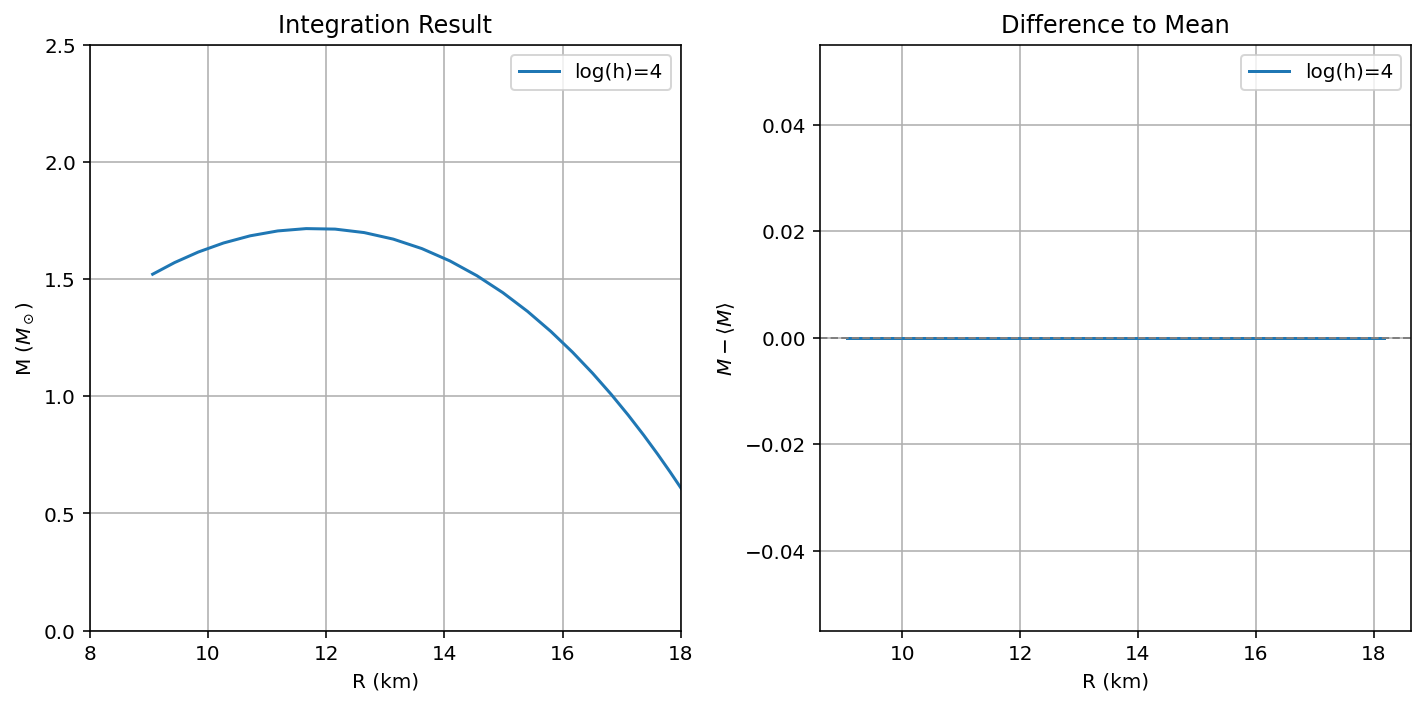

In [21]:
# Compute mean at each data point
M_stack = np.stack(MM)  
R_stack = np.stack(RR)  
M_mean = np.mean(M_stack, axis=0)
R_mean = np.mean(R_stack, axis=0)

# Compute differences
M_diff = M_stack - M_mean  
R_diff = R_stack - R_mean  

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5), dpi=144)

# Original plot
axs[0].set_xlim(8, 18)
axs[0].set_ylim(0, 2.5)
axs[0].grid()
axs[0].set_xlabel("R (km)")
axs[0].set_ylabel(r"M ($M_\odot$)")
for M, R, H in zip(MM, RR, stepArr):
    print(M, R)
    axs[0].plot(R, M, label=f"log(h)={H}")
axs[0].legend()
axs[0].set_title("Integration Result")

# Difference to mean in log scale
for diff, H in zip(M_diff, stepArr):
    axs[1].plot(R_arr, diff, label=f"log(h)={H}")
axs[1].axhline(0, color='gray', ls='--', linewidth=1)
axs[1].set_xlabel("R (km)")
axs[1].set_ylabel(r"$M - \langle M \rangle$")
axs[1].set_title("Difference to Mean")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [22]:
def nu_rhs(r, y, p, m):
    rr = 2 * (m + 4*np.pi*(r**3) * p) / (r*(r-2*m))
    return rr

# the new rk4 function for computing \nu numerically (with 6 params, so the previous is not overridden)
def rk4_step_nu(func, r, y, h, p, m):
    k1 = np.array(func(r, y, p, m))
    k2 = np.array(func(r + h/2, y + h*k1/2, p, m))
    k3 = np.array(func(r + h/2, y + h*k2/2, p, m))
    k4 = np.array(func(r + h, y + h*k3, p, m))
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

In [23]:
# The initial \nu_c we pick is 0
Sol_nu = np.zeros(len(R_l)) 

Sol_arr = np.array(Sol)

counter = 0
for i, r in enumerate(R_l[:-1]):

    newStep = rk4_step_nu(nu_rhs, r, Sol_nu[i], h, Sol_arr[i,1], Sol_arr[i,0])
    Sol_nu[i+1] = newStep
    
    counter += 1
    if counter % 1000 == 0: print(counter, newStep)


1000 0.0005868026547992021
2000 0.0023248934296073135
3000 0.0052120281600250805
4000 0.009244474231972895
5000 0.014417012978397379
6000 0.02072294082115621
7000 0.02815407076844987
8000 0.03670073435369706
9000 0.046351784093966106
10000 0.05709459655901699
11000 0.06891507615878037
12000 0.08179765977583554
13000 0.09572532238985763
14000 0.1106795838630315
15000 0.1266405170790162
16000 0.14358675765309856
17000 0.16149551545751403
18000 0.18034258823324323
19000 0.20010237758755944
20000 0.22074790770465086
21000 0.24225084712413805
22000 0.26458153396842776
23000 0.287709005023621
24000 0.31160102909898246
25000 0.3362241451055067
26000 0.3615437053033589
27000 0.38752392416946985
28000 0.4141279333285151
29000 0.4413178429713078
30000 0.46905481015251155
31000 0.49729911431300877
32000 0.5260102403097876
33000 0.5551469691567837
34000 0.5846674765831352
35000 0.6145294394005412
36000 0.6446901495396324
37000 0.675106635467643
38000 0.7057357905386118
39000 0.7365345076559027
400

In [24]:
import pickle

with open("../numpy_grid/PMSol_1e-3.pkl", "wb") as f:                        
    pickle.dump(SolArr, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("../numpy_grid/Rgrid_1e-3.pkl", "wb") as f:                        
    pickle.dump(RArr, f, protocol=pickle.HIGHEST_PROTOCOL)
